# AutoGluon Tabular Forecasting

## Import Library

In [257]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For time series
from typing import List
# from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

In [258]:
def download_kaggle(kaggle_command="kaggle competitions download -c liver-fibrosis-severity-prediction"):

  # Get Kaggle Key
  kaggle_username = userdata.get("KAGGLE_USER")
  kaggle_key = userdata.get("KAGGLE_KEY")
  if not kaggle_username or not kaggle_key:
      print("Error: Kaggle_USERNAME or Kaggle_KEY not found in Colab Secrets.")
      return

  # Write the credentials to ~/.kaggle/kaggle.json
  kaggle_dir = os.path.expanduser("~/.kaggle")
  os.makedirs(kaggle_dir, exist_ok=True)

  # Create JSON
  kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
  with open(kaggle_json_path, "w") as f:
      f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')
  os.chmod(kaggle_json_path, 0o600)

  try:
      os.system(kaggle_command)
      print("\n--- Download complete! ---")
      os.system("ls -la")
      os.system("unzip -o '*.zip' && rm -f *.zip")
      os.system("ls -la")

  except Exception as e:
      print(f"An error occurred during download: {e}")

In [259]:
download_kaggle(
    "kaggle competitions download -c individual-test-temperature-prediction"
)


--- Download complete! ---


## Explore Dataset

In [260]:
df_train = pd.read_csv("/content/IOT_Train.csv")
df_train

,mac,station_name,tambon_code,tambon_namt,amphur_code,amphur_namt,province_code,province_namt,latitude,longitude,time,humid,light,pm10,pm2.5,rainfall,wind_direct,wind_speed,temp
0,3C71BF18EA64,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,2022-07-20 15:00:00+07:00,70.6,59.0,NaN,NaN,0.0,45.0,4.3,32.6
1,3C71BF18EA64,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,2022-05-16 09:00:00+07:00,62.3,76.0,NaN,NaN,0.0,45.0,1.9,37.9
2,3C71BF18EA64,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,2022-06-26 19:00:00+07:00,90.3,0.0,NaN,NaN,0.0,135.0,3.2,26.4
3,3C71BF18EA64,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,2022-07-16 04:00:00+07:00,91.7,0.0,NaN,NaN,0.0,157.5,0.0,25.6
4,3C71BF18EA64,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,2022-05-30 08:00:00+07:00,59.1,71.0,NaN,NaN,0.0,180.0,2.3,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13630,3C71BF18CEA4,โรงเรียนหนองสูงสามัคคีวิทยา_2,490706,หนองสูงเหนือ,4907,หนองสูง,49,มุกดาหาร,16.494229,104.350891,2022-06-14 01:00:00+07:00,97.9,0.0,NaN,NaN,4.2,0.0,0.0,23.5
13631,3C71BF18CEA4,โรงเรียนหนองสูงสามัคคีวิทยา_2,490706,หนองสูงเหนือ,4907,หนองสูง,49,มุกดาหาร,16.494229,104.350891,2022-05-03 02:00:00+07:00,80.6,0.0,NaN,NaN,0.0,135.0,2.9,19.3
13632,3C71BF18CEA4,โรงเรียนหนองสูงสามัคคีวิทยา_2,490706,หนองสูงเหนือ,4907,หนองสูง,49,มุกดาหาร,16.494229,104.350891,2022-05-19 06:00:00+07:00,87.9,37.0,NaN,NaN,0.0,45.0,3.0,24.5
13633,3C71BF18CEA4,โรงเรียนหนองสูงสามัคคีวิทยา_2,490706,หนองสูงเหนือ,4907,หนองสูง,49,มุกดาหาร,16.494229,104.350891,2022-06-15 02:00:00+07:00,89.9,0.0,NaN,NaN,0.0,315.0,0.0,27.3


In [261]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13635 entries, 0 to 13634
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mac            13635 non-null  object 
 1   station_name   13635 non-null  object 
 2   tambon_code    13635 non-null  int64  
 3   tambon_namt    13635 non-null  object 
 4   amphur_code    13635 non-null  int64  
 5   amphur_namt    13635 non-null  object 
 6   province_code  13635 non-null  int64  
 7   province_namt  13635 non-null  object 
 8   latitude       13635 non-null  float64
 9   longitude      13635 non-null  float64
 10  time           13635 non-null  object 
 11  humid          13635 non-null  float64
 12  light          13635 non-null  float64
 13  pm10           6841 non-null   float64
 14  pm2.5          6841 non-null   float64
 15  rainfall       13635 non-null  float64
 16  wind_direct    13635 non-null  float64
 17  wind_speed     13635 non-null  float64
 18  temp  

In [262]:
print(len(df_train["mac"].unique()))
print(len(df_train["station_name"].unique()))

8
8


In [263]:
df_train["time"] = pd.to_datetime(df_train["time"])
df_train = df_train.sort_values(by="time")
df_train["time"]

,time
6361,2022-05-02 00:00:00+07:00
8429,2022-05-02 00:00:00+07:00
1678,2022-05-02 00:00:00+07:00
11871,2022-05-02 00:00:00+07:00
13614,2022-05-02 00:00:00+07:00
...,...
55,2022-07-31 21:00:00+07:00
10275,2022-07-31 21:00:00+07:00
1806,2022-07-31 21:00:00+07:00
8545,2022-07-31 21:00:00+07:00


In [264]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13635 entries, 6361 to 6830
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype                    
---  ------         --------------  -----                    
 0   mac            13635 non-null  object                   
 1   station_name   13635 non-null  object                   
 2   tambon_code    13635 non-null  int64                    
 3   tambon_namt    13635 non-null  object                   
 4   amphur_code    13635 non-null  int64                    
 5   amphur_namt    13635 non-null  object                   
 6   province_code  13635 non-null  int64                    
 7   province_namt  13635 non-null  object                   
 8   latitude       13635 non-null  float64                  
 9   longitude      13635 non-null  float64                  
 10  time           13635 non-null  datetime64[ns, UTC+07:00]
 11  humid          13635 non-null  float64                  
 12  light          13635 

### Time Features

In [265]:
def extract_time_features(df: pd.DataFrame, time_columns: list = None) -> pd.DataFrame:
    """
    Extracts time-based features from specified columns in a DataFrame.
    If time_columns is not provided, it attempts to infer time columns
    by checking common time-related column names.

    Args:
        df (pd.DataFrame): The input DataFrame.
        time_columns (list, optional): A list of column names containing time data.
                                        If None, common time-related column names will be checked.

    Returns:
        pd.DataFrame: The DataFrame with new time feature columns.
    """

    df_copy = df.copy()

    # Common time-related column name patterns for inference
    if time_columns is None:
        possible_time_col_patterns = [
            'time', 'date', 'timestamp', 'datetime', 'created_at',
            'updated_at', 'ts', 'event_time', 'start_time', 'end_time'
        ]
        inferred_time_columns = [
            col for col in df_copy.columns
            if any(pattern in col.lower() for pattern in possible_time_col_patterns)
        ]
        if not inferred_time_columns:
            print("Warning: No time columns specified and no common time-related columns found. "
                  "Returning original DataFrame.")
            return df_copy
        time_columns = inferred_time_columns
        print(f"Inferred time columns: {time_columns}")

    # Possible time formats to try for robust parsing
    # Ordered from most specific/common to more general
    possible_time_formats = [
        "%Y-%m-%d %H:%M:%S.%f",  # 2025-07-05 13:42:29.123456
        "%Y-%m-%d %H:%M:%S",    # 2025-07-05 13:42:29
        "%Y-%m-%dT%H:%M:%S.%fZ",# ISO 8601 with Z (UTC)
        "%Y-%m-%dT%H:%M:%S",    # ISO 8601 without Z
        "%Y/%m/%d %H:%M:%S",    # 2025/07/05 13:42:29
        "%d-%m-%Y %H:%M:%S",    # 05-07-2025 13:42:29
        "%m/%d/%Y %I:%M:%S %p", # 07/05/2025 01:42:29 PM
        "%d/%m/%Y %H:%M",       # 05/07/2025 13:42
        "%Y-%m-%d",             # 2025-07-05
        "%d-%m-%Y",             # 05-07-2025
        "%m/%d/%Y",             # 07/05/2025
        "%H:%M:%S",             # 13:42:29
        "%H:%M",                # 13:42
        "%I:%M %p"              # 01:42 PM
    ]

    for col in time_columns:
        if col not in df_copy.columns:
            print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")
            continue

        # Convert to datetime, coercing errors to NaT (Not a Time)
        # We try multiple formats with errors='coerce' to handle mixed formats
        df_copy[f'{col}_dt'] = pd.to_datetime(df_copy[col], errors='coerce', infer_datetime_format=True)

        # Drop rows where conversion failed for this column, or handle as NaT
        # For simplicity in feature extraction, we'll proceed with NaT values
        # If a column is entirely NaT after conversion, it's probably not a time column
        if df_copy[f'{col}_dt'].isnull().all() and not df_copy[col].isnull().all():
            print(f"Warning: Column '{col}' could not be converted to datetime. Skipping feature extraction for this column.")
            df_copy = df_copy.drop(columns=[f'{col}_dt'])
            continue

        # Extract features
        dt_col = df_copy[f'{col}_dt'].dt
        df_copy[f'{col}_year'] = dt_col.year
        df_copy[f'{col}_month'] = dt_col.month
        df_copy[f'{col}_day'] = dt_col.day
        df_copy[f'{col}_hour'] = dt_col.hour
        df_copy[f'{col}_minute'] = dt_col.minute
        df_copy[f'{col}_second'] = dt_col.second
        df_copy[f'{col}_dayofweek'] = dt_col.dayofweek # Monday=0, Sunday=6
        df_copy[f'{col}_dayofyear'] = dt_col.dayofyear
        df_copy[f'{col}_weekofyear'] = dt_col.isocalendar().week.astype(int)
        df_copy[f'{col}_quarter'] = dt_col.quarter
        df_copy[f'{col}_is_weekend'] = dt_col.dayofweek.isin([5, 6]).astype(int)
        df_copy[f'{col}_season'] = (dt_col.month % 12 + 3) // 3 # Simple season mapping
        df_copy[f'{col}_is_month_start'] = dt_col.is_month_start.astype(int)
        df_copy[f'{col}_is_month_end'] = dt_col.is_month_end.astype(int)
        df_copy[f'{col}_is_quarter_start'] = dt_col.is_quarter_start.astype(int)
        df_copy[f'{col}_is_quarter_end'] = dt_col.is_quarter_end.astype(int)
        df_copy[f'{col}_is_year_start'] = dt_col.is_year_start.astype(int)
        df_copy[f'{col}_is_year_end'] = dt_col.is_year_end.astype(int)

        # Optional: Add cyclical features (sin/cos transformations for hour, dayofweek, etc.)
        # These are useful for models to understand cyclical patterns without arbitrary breaks
        # Example for hour
        df_copy[f'{col}_hour_sin'] = np.sin(2 * np.pi * dt_col.hour / 24)
        df_copy[f'{col}_hour_cos'] = np.cos(2 * np.pi * dt_col.hour / 24)

    return df_copy

In [266]:
df_train = extract_time_features(df=df_train, time_columns=["time"])
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13635 entries, 6361 to 6830
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype                    
---  ------                 --------------  -----                    
 0   mac                    13635 non-null  object                   
 1   station_name           13635 non-null  object                   
 2   tambon_code            13635 non-null  int64                    
 3   tambon_namt            13635 non-null  object                   
 4   amphur_code            13635 non-null  int64                    
 5   amphur_namt            13635 non-null  object                   
 6   province_code          13635 non-null  int64                    
 7   province_namt          13635 non-null  object                   
 8   latitude               13635 non-null  float64                  
 9   longitude              13635 non-null  float64                  
 10  time                   13635 non-null  datetime64

In [267]:
df_train = df_train.drop(columns=["time_dt", "mac"])
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13635 entries, 6361 to 6830
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype                    
---  ------                 --------------  -----                    
 0   station_name           13635 non-null  object                   
 1   tambon_code            13635 non-null  int64                    
 2   tambon_namt            13635 non-null  object                   
 3   amphur_code            13635 non-null  int64                    
 4   amphur_namt            13635 non-null  object                   
 5   province_code          13635 non-null  int64                    
 6   province_namt          13635 non-null  object                   
 7   latitude               13635 non-null  float64                  
 8   longitude              13635 non-null  float64                  
 9   time                   13635 non-null  datetime64[ns, UTC+07:00]
 10  humid                  13635 non-null  float64   

In [268]:
df_train = df_train.drop(columns=["time"])
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13635 entries, 6361 to 6830
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   station_name           13635 non-null  object 
 1   tambon_code            13635 non-null  int64  
 2   tambon_namt            13635 non-null  object 
 3   amphur_code            13635 non-null  int64  
 4   amphur_namt            13635 non-null  object 
 5   province_code          13635 non-null  int64  
 6   province_namt          13635 non-null  object 
 7   latitude               13635 non-null  float64
 8   longitude              13635 non-null  float64
 9   humid                  13635 non-null  float64
 10  light                  13635 non-null  float64
 11  pm10                   6841 non-null   float64
 12  pm2.5                  6841 non-null   float64
 13  rainfall               13635 non-null  float64
 14  wind_direct            13635 non-null  float64
 15  wind_

In [269]:
print(df_train["station_name"].unique())
# print(df_train["mac"].unique())
print(df_train["tambon_namt"].unique())
print(df_train["province_namt"].unique())

['โรงเรียนท่าข้ามวิทยา' 'โรงเรียนบ้านนา' 'บ้านนา_2'
 'โรงเรียนสามเสนนอก(ประชาราษฎร์อนุกูล)' 'โรงเรียนหนองสูงสามัคคีวิทยา_2'
 'บ้านนาสะแบง_2' 'บ้านสำโรงเกียรติ_2' 'โรงเรียนสรรพวิทยาคม']
['ท่าข้าม' 'สถาน' 'กำปัง' 'ดินแดง' 'หนองสูงเหนือ' 'นาสะแบง' 'บักดอง'
 'แม่สอด']
['ชุมพร' 'น่าน' 'นครราชสีมา' 'กรุงเทพมหานคร' 'มุกดาหาร' 'บึงกาฬ'
 'ศรีสะเกษ' 'ตาก']


In [270]:
df_train

,station_name,tambon_code,tambon_namt,amphur_code,amphur_namt,province_code,province_namt,latitude,longitude,humid,...,time_is_weekend,time_season,time_is_month_start,time_is_month_end,time_is_quarter_start,time_is_quarter_end,time_is_year_start,time_is_year_end,time_hour_sin,time_hour_cos
6361,โรงเรียนท่าข้ามวิทยา,860206,ท่าข้าม,8602,ท่าแซะ,86,ชุมพร,10.579849,99.113146,93.0,...,0,2,0,0,0,0,0,0,0.000000,1.000000
8429,โรงเรียนบ้านนา,550404,สถาน,5504,นาน้อย,55,น่าน,18.241106,100.690577,82.9,...,0,2,0,0,0,0,0,0,0.000000,1.000000
1678,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,94.7,...,0,2,0,0,0,0,0,0,0.000000,1.000000
11871,โรงเรียนสามเสนนอก(ประชาราษฎร์อนุกูล),102601,ดินแดง,1026,ดินแดง,10,กรุงเทพมหานคร,13.777972,100.569662,76.7,...,0,2,0,0,0,0,0,0,0.000000,1.000000
13614,โรงเรียนหนองสูงสามัคคีวิทยา_2,490706,หนองสูงเหนือ,4907,หนองสูง,49,มุกดาหาร,16.494229,104.350891,97.7,...,0,2,0,0,0,0,0,0,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,92.2,...,1,3,0,1,0,0,0,0,-0.707107,0.707107
10275,โรงเรียนสามเสนนอก(ประชาราษฎร์อนุกูล),102601,ดินแดง,1026,ดินแดง,10,กรุงเทพมหานคร,13.777972,100.569662,80.7,...,1,3,0,1,0,0,0,0,-0.707107,0.707107
1806,บ้านนาสะแบง_2,380704,นาสะแบง,3807,ศรีวิไล,38,บึงกาฬ,18.142499,103.806521,85.6,...,1,3,0,1,0,0,0,0,-0.707107,0.707107
8545,โรงเรียนสรรพวิทยาคม,630601,แม่สอด,6306,แม่สอด,63,ตาก,16.712990,98.573417,86.2,...,1,3,0,1,0,0,0,0,-0.707107,0.707107


### One Hot Encoding

In [271]:
def onehot_encoding(df, feature):

  dummies = pd.get_dummies(df[feature])
  df = pd.concat([df, dummies], axis = 1)
  df = df.drop(columns=[feature])

  return df

In [272]:
df_train = onehot_encoding(df_train, 'station_name')
df_train = onehot_encoding(df_train, 'tambon_namt')
df_train = onehot_encoding(df_train, 'province_namt')
df_train = onehot_encoding(df_train, 'amphur_namt')

df_train

,tambon_code,amphur_code,province_code,latitude,longitude,humid,light,pm10,pm2.5,rainfall,...,มุกดาหาร,ศรีสะเกษ,ขุนหาญ,ดินแดง,ท่าแซะ,นาน้อย,ศรีวิไล,หนองสูง,แม่สอด,โนนไทย
6361,860206,8602,86,10.579849,99.113146,93.0,0.0,NaN,NaN,0.0,...,False,False,False,False,True,False,False,False,False,False
8429,550404,5504,55,18.241106,100.690577,82.9,0.0,21.0,20.0,0.0,...,False,False,False,False,False,True,False,False,False,False
1678,300903,3009,30,15.112831,102.052114,94.7,0.0,NaN,NaN,0.9,...,False,False,False,False,False,False,False,False,False,True
11871,102601,1026,10,13.777972,100.569662,76.7,0.0,3.0,2.0,0.0,...,False,False,False,True,False,False,False,False,False,False
13614,490706,4907,49,16.494229,104.350891,97.7,0.0,NaN,NaN,1.5,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,300903,3009,30,15.112831,102.052114,92.2,0.0,NaN,NaN,21.5,...,False,False,False,False,False,False,False,False,False,True
10275,102601,1026,10,13.777972,100.569662,80.7,0.0,NaN,NaN,0.9,...,False,False,False,True,False,False,False,False,False,False
1806,380704,3807,38,18.142499,103.806521,85.6,0.0,2.0,1.0,0.0,...,False,False,False,False,False,False,True,False,False,False
8545,630601,6306,63,16.712990,98.573417,86.2,0.0,4.0,3.0,0.0,...,False,False,False,False,False,False,False,False,True,False


In [273]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13635 entries, 6361 to 6830
Data columns (total 65 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   tambon_code                           13635 non-null  int64  
 1   amphur_code                           13635 non-null  int64  
 2   province_code                         13635 non-null  int64  
 3   latitude                              13635 non-null  float64
 4   longitude                             13635 non-null  float64
 5   humid                                 13635 non-null  float64
 6   light                                 13635 non-null  float64
 7   pm10                                  6841 non-null   float64
 8   pm2.5                                 6841 non-null   float64
 9   rainfall                              13635 non-null  float64
 10  wind_direct                           13635 non-null  float64
 11  wind_speed        

In [274]:
df_train = df_train.drop(columns=[
    "time_year", "time_is_year_start", "time_is_year_end"
])

df_train

,tambon_code,amphur_code,province_code,latitude,longitude,humid,light,pm10,pm2.5,rainfall,...,มุกดาหาร,ศรีสะเกษ,ขุนหาญ,ดินแดง,ท่าแซะ,นาน้อย,ศรีวิไล,หนองสูง,แม่สอด,โนนไทย
6361,860206,8602,86,10.579849,99.113146,93.0,0.0,NaN,NaN,0.0,...,False,False,False,False,True,False,False,False,False,False
8429,550404,5504,55,18.241106,100.690577,82.9,0.0,21.0,20.0,0.0,...,False,False,False,False,False,True,False,False,False,False
1678,300903,3009,30,15.112831,102.052114,94.7,0.0,NaN,NaN,0.9,...,False,False,False,False,False,False,False,False,False,True
11871,102601,1026,10,13.777972,100.569662,76.7,0.0,3.0,2.0,0.0,...,False,False,False,True,False,False,False,False,False,False
13614,490706,4907,49,16.494229,104.350891,97.7,0.0,NaN,NaN,1.5,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,300903,3009,30,15.112831,102.052114,92.2,0.0,NaN,NaN,21.5,...,False,False,False,False,False,False,False,False,False,True
10275,102601,1026,10,13.777972,100.569662,80.7,0.0,NaN,NaN,0.9,...,False,False,False,True,False,False,False,False,False,False
1806,380704,3807,38,18.142499,103.806521,85.6,0.0,2.0,1.0,0.0,...,False,False,False,False,False,False,True,False,False,False
8545,630601,6306,63,16.712990,98.573417,86.2,0.0,4.0,3.0,0.0,...,False,False,False,False,False,False,False,False,True,False


In [275]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13635 entries, 6361 to 6830
Data columns (total 62 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   tambon_code                           13635 non-null  int64  
 1   amphur_code                           13635 non-null  int64  
 2   province_code                         13635 non-null  int64  
 3   latitude                              13635 non-null  float64
 4   longitude                             13635 non-null  float64
 5   humid                                 13635 non-null  float64
 6   light                                 13635 non-null  float64
 7   pm10                                  6841 non-null   float64
 8   pm2.5                                 6841 non-null   float64
 9   rainfall                              13635 non-null  float64
 10  wind_direct                           13635 non-null  float64
 11  wind_speed        

In [276]:
df_train.columns

Index(['tambon_code', 'amphur_code', 'province_code', 'latitude', 'longitude',
       'humid', 'light', 'pm10', 'pm2.5', 'rainfall', 'wind_direct',
       'wind_speed', 'temp', 'time_month', 'time_day', 'time_hour',
       'time_minute', 'time_second', 'time_dayofweek', 'time_dayofyear',
       'time_weekofyear', 'time_quarter', 'time_is_weekend', 'time_season',
       'time_is_month_start', 'time_is_month_end', 'time_is_quarter_start',
       'time_is_quarter_end', 'time_hour_sin', 'time_hour_cos', 'บ้านนา_2',
       'บ้านนาสะแบง_2', 'บ้านสำโรงเกียรติ_2', 'โรงเรียนท่าข้ามวิทยา',
       'โรงเรียนบ้านนา', 'โรงเรียนสรรพวิทยาคม',
       'โรงเรียนสามเสนนอก(ประชาราษฎร์อนุกูล)', 'โรงเรียนหนองสูงสามัคคีวิทยา_2',
       'กำปัง', 'ดินแดง', 'ท่าข้าม', 'นาสะแบง', 'บักดอง', 'สถาน',
       'หนองสูงเหนือ', 'แม่สอด', 'กรุงเทพมหานคร', 'ชุมพร', 'ตาก', 'นครราชสีมา',
       'น่าน', 'บึงกาฬ', 'มุกดาหาร', 'ศรีสะเกษ', 'ขุนหาญ', 'ดินแดง', 'ท่าแซะ',
       'นาน้อย', 'ศรีวิไล', 'หนองสูง', 'แม่สอด', 'โนนไทย'],


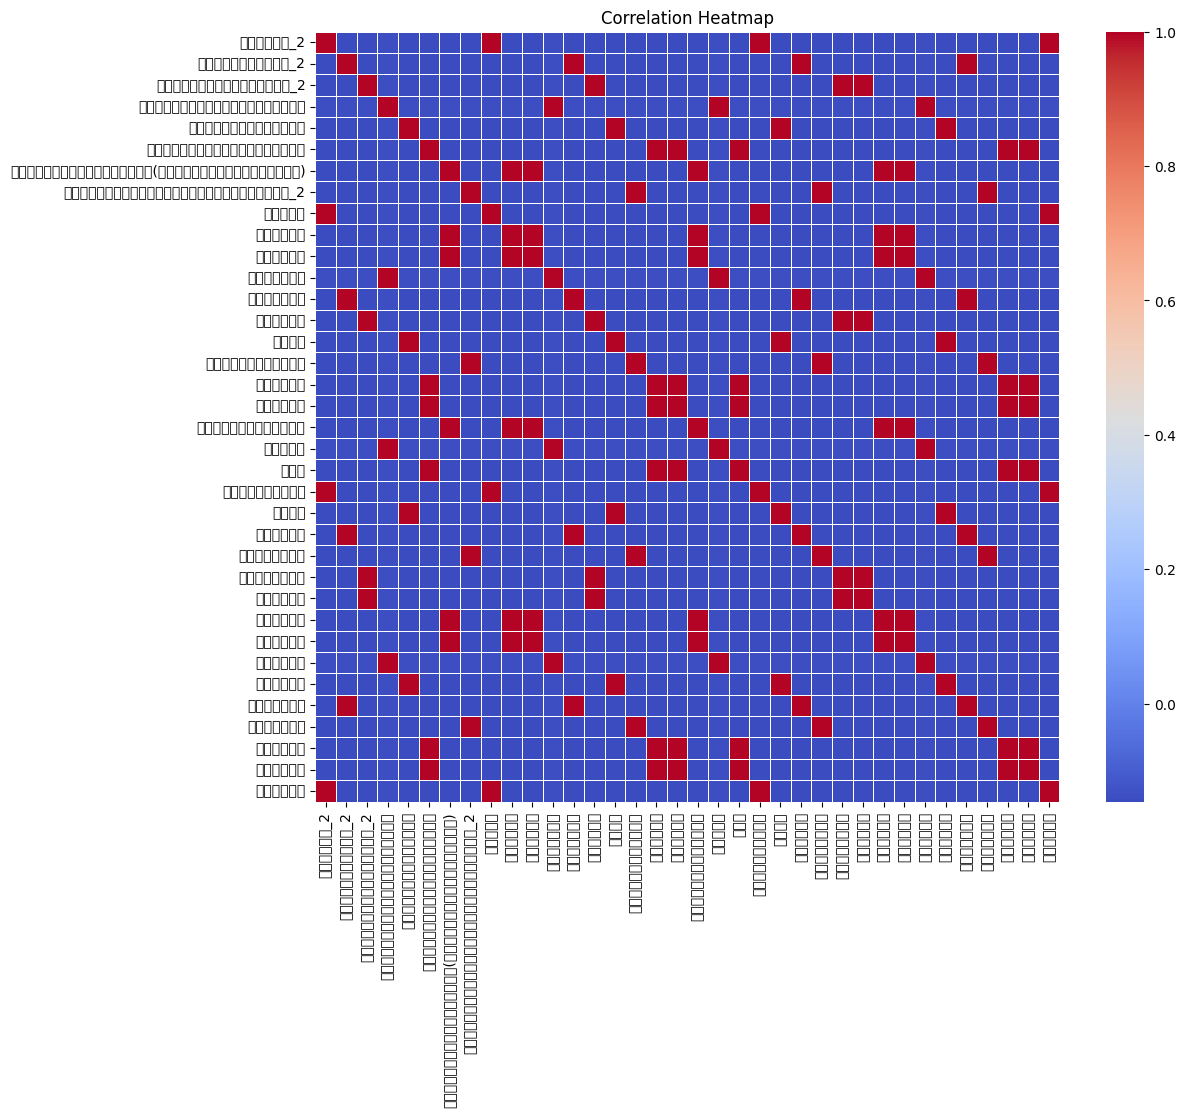

In [277]:
# Select only numerical columns
df_plot = df_train[[
    'บ้านนา_2',
       'บ้านนาสะแบง_2', 'บ้านสำโรงเกียรติ_2', 'โรงเรียนท่าข้ามวิทยา',
       'โรงเรียนบ้านนา', 'โรงเรียนสรรพวิทยาคม',
       'โรงเรียนสามเสนนอก(ประชาราษฎร์อนุกูล)', 'โรงเรียนหนองสูงสามัคคีวิทยา_2',
       'กำปัง', 'ดินแดง', 'ท่าข้าม', 'นาสะแบง', 'บักดอง', 'สถาน',
       'หนองสูงเหนือ', 'แม่สอด', 'กรุงเทพมหานคร', 'ชุมพร', 'ตาก', 'นครราชสีมา',
       'น่าน', 'บึงกาฬ', 'มุกดาหาร', 'ศรีสะเกษ', 'ขุนหาญ', 'ดินแดง', 'ท่าแซะ',
       'นาน้อย', 'ศรีวิไล', 'หนองสูง', 'แม่สอด', 'โนนไทย'
]]
numerical_columns = df_plot.select_dtypes(include=['float64', 'int64', 'bool'])
numerical_columns

# Calculate the correlation matrix
corr_matrix = numerical_columns.corr()
pd.DataFrame(corr_matrix)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Visualize Dataset

In [278]:
df_eda = df_train.copy()

In [279]:
def plot_violin_box_distribution(df, columns):
    """
    Plots violin plots, box plots, and distribution plots for specified columns.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        columns (list): List of columns to plot.
    """
    # Filter columns that exist in the DataFrame
    valid_columns = [col for col in columns if col in df.columns]

    # Calculate the number of rows needed (3 plots per column)
    num_columns = len(valid_columns)
    num_rows = num_columns  # One row per column
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows))

    # If only one column, axes will be 1D, so reshape it
    if num_columns == 1:
        axes = axes.reshape(1, -1)

    # Loop through the valid columns and plot
    for i, col in enumerate(valid_columns):
        # Violin Plot
        sns.violinplot(data=df, x=col, ax=axes[i, 0], palette='viridis')
        axes[i, 0].set_title(f'Violin Plot of {col}')
        axes[i, 0].set_xlabel(col)

        # Box Plot
        sns.boxplot(data=df, x=col, ax=axes[i, 1], palette='viridis')
        axes[i, 1].set_title(f'Box Plot of {col}')
        axes[i, 1].set_xlabel(col)

        # Distribution Plot (Histogram with KDE)
        sns.histplot(data=df, x=col, kde=True, ax=axes[i, 2], color='skyblue')
        axes[i, 2].set_title(f'Distribution of {col}')
        axes[i, 2].set_xlabel(col)
        axes[i, 2].set_ylabel('Density')

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

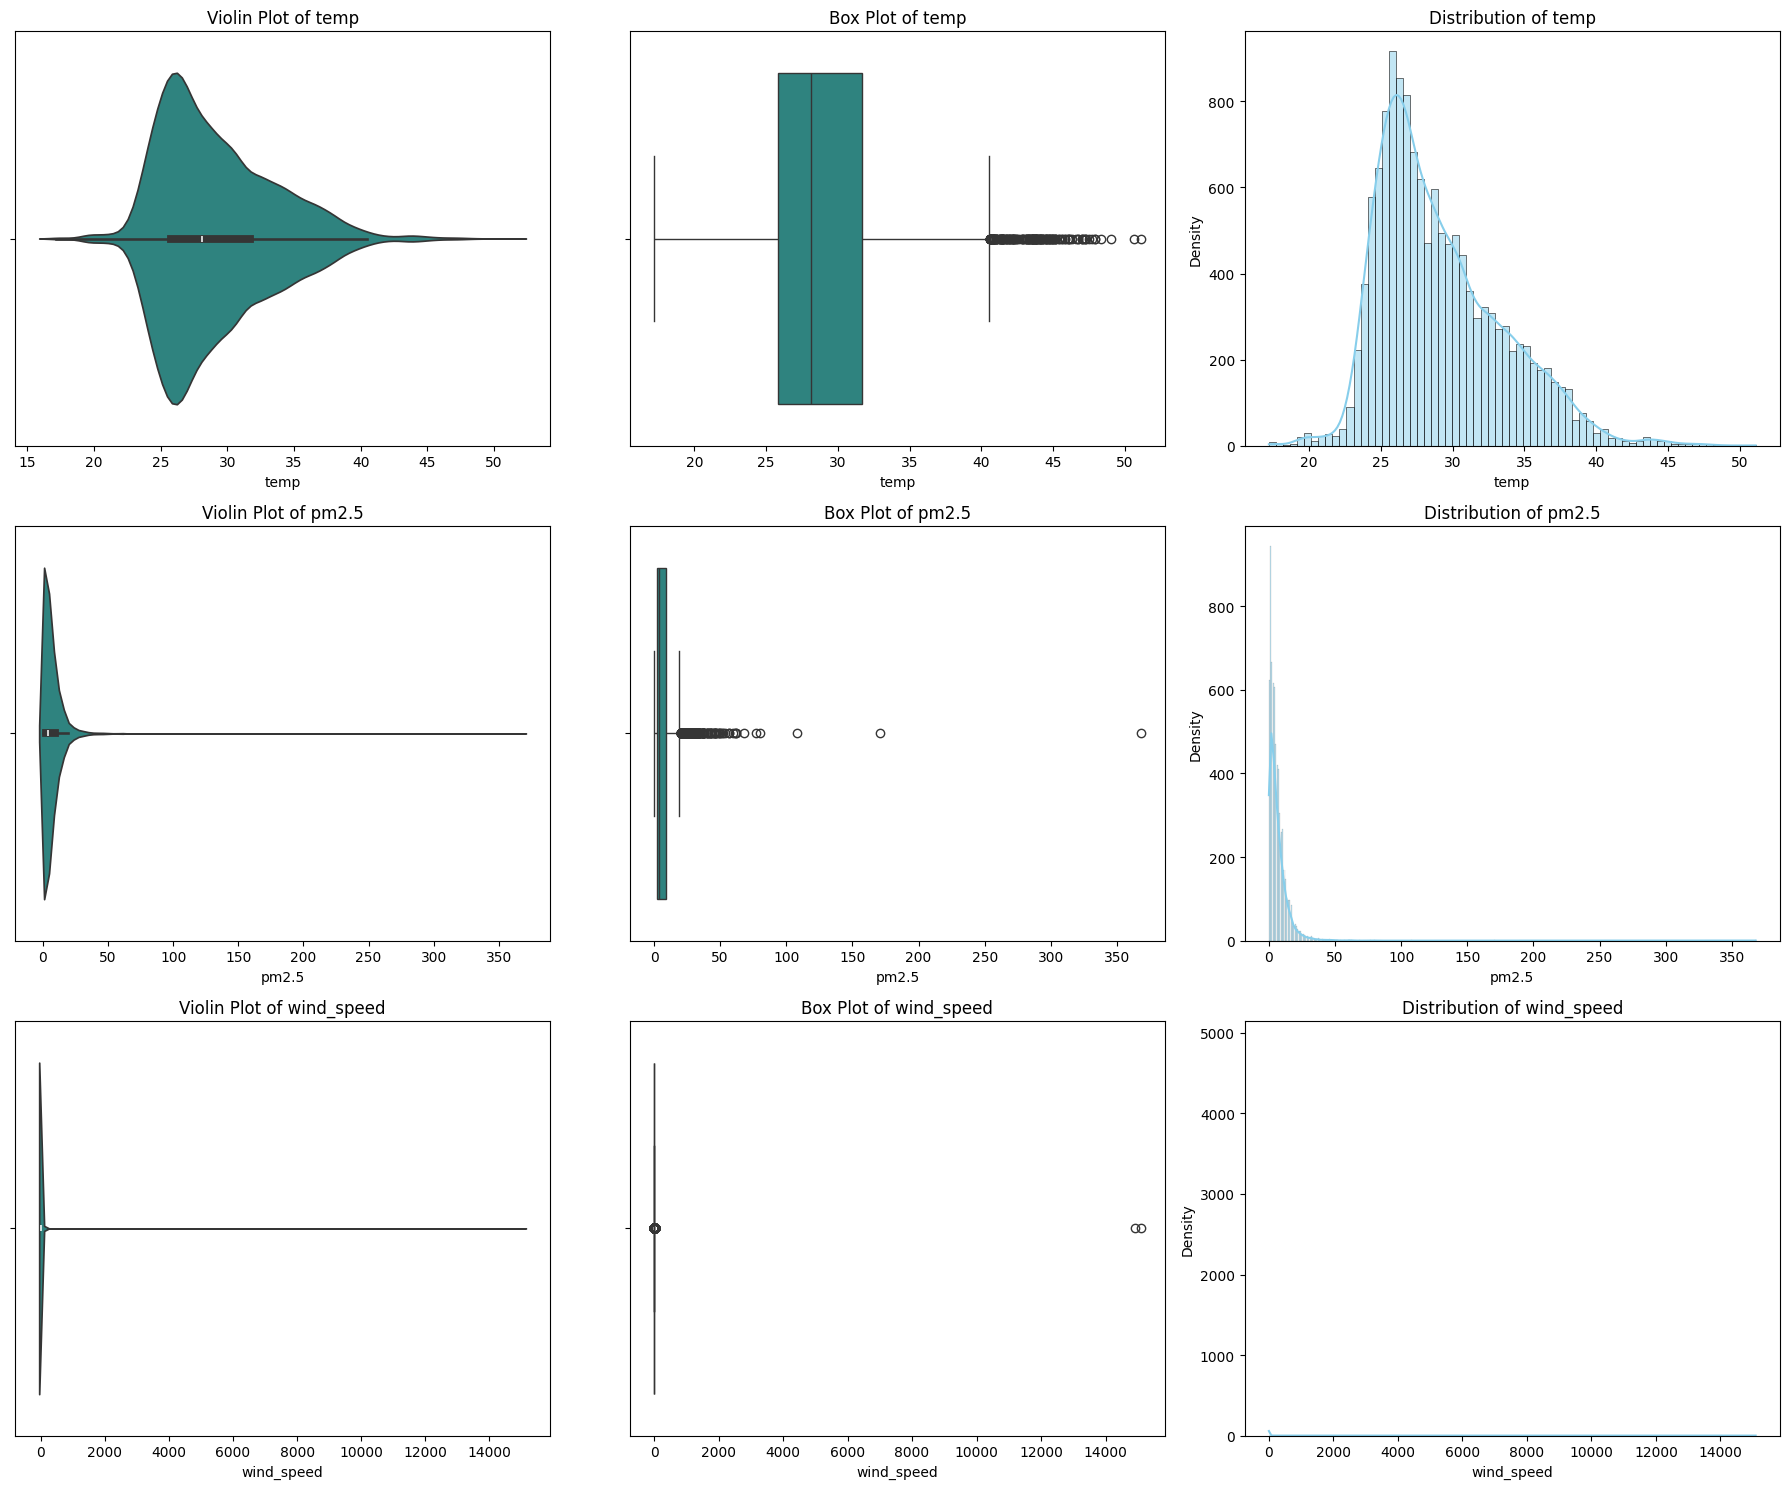

In [280]:
plot_violin_box_distribution(df_eda, columns=["temp", "pm2.5", "wind_speed"])

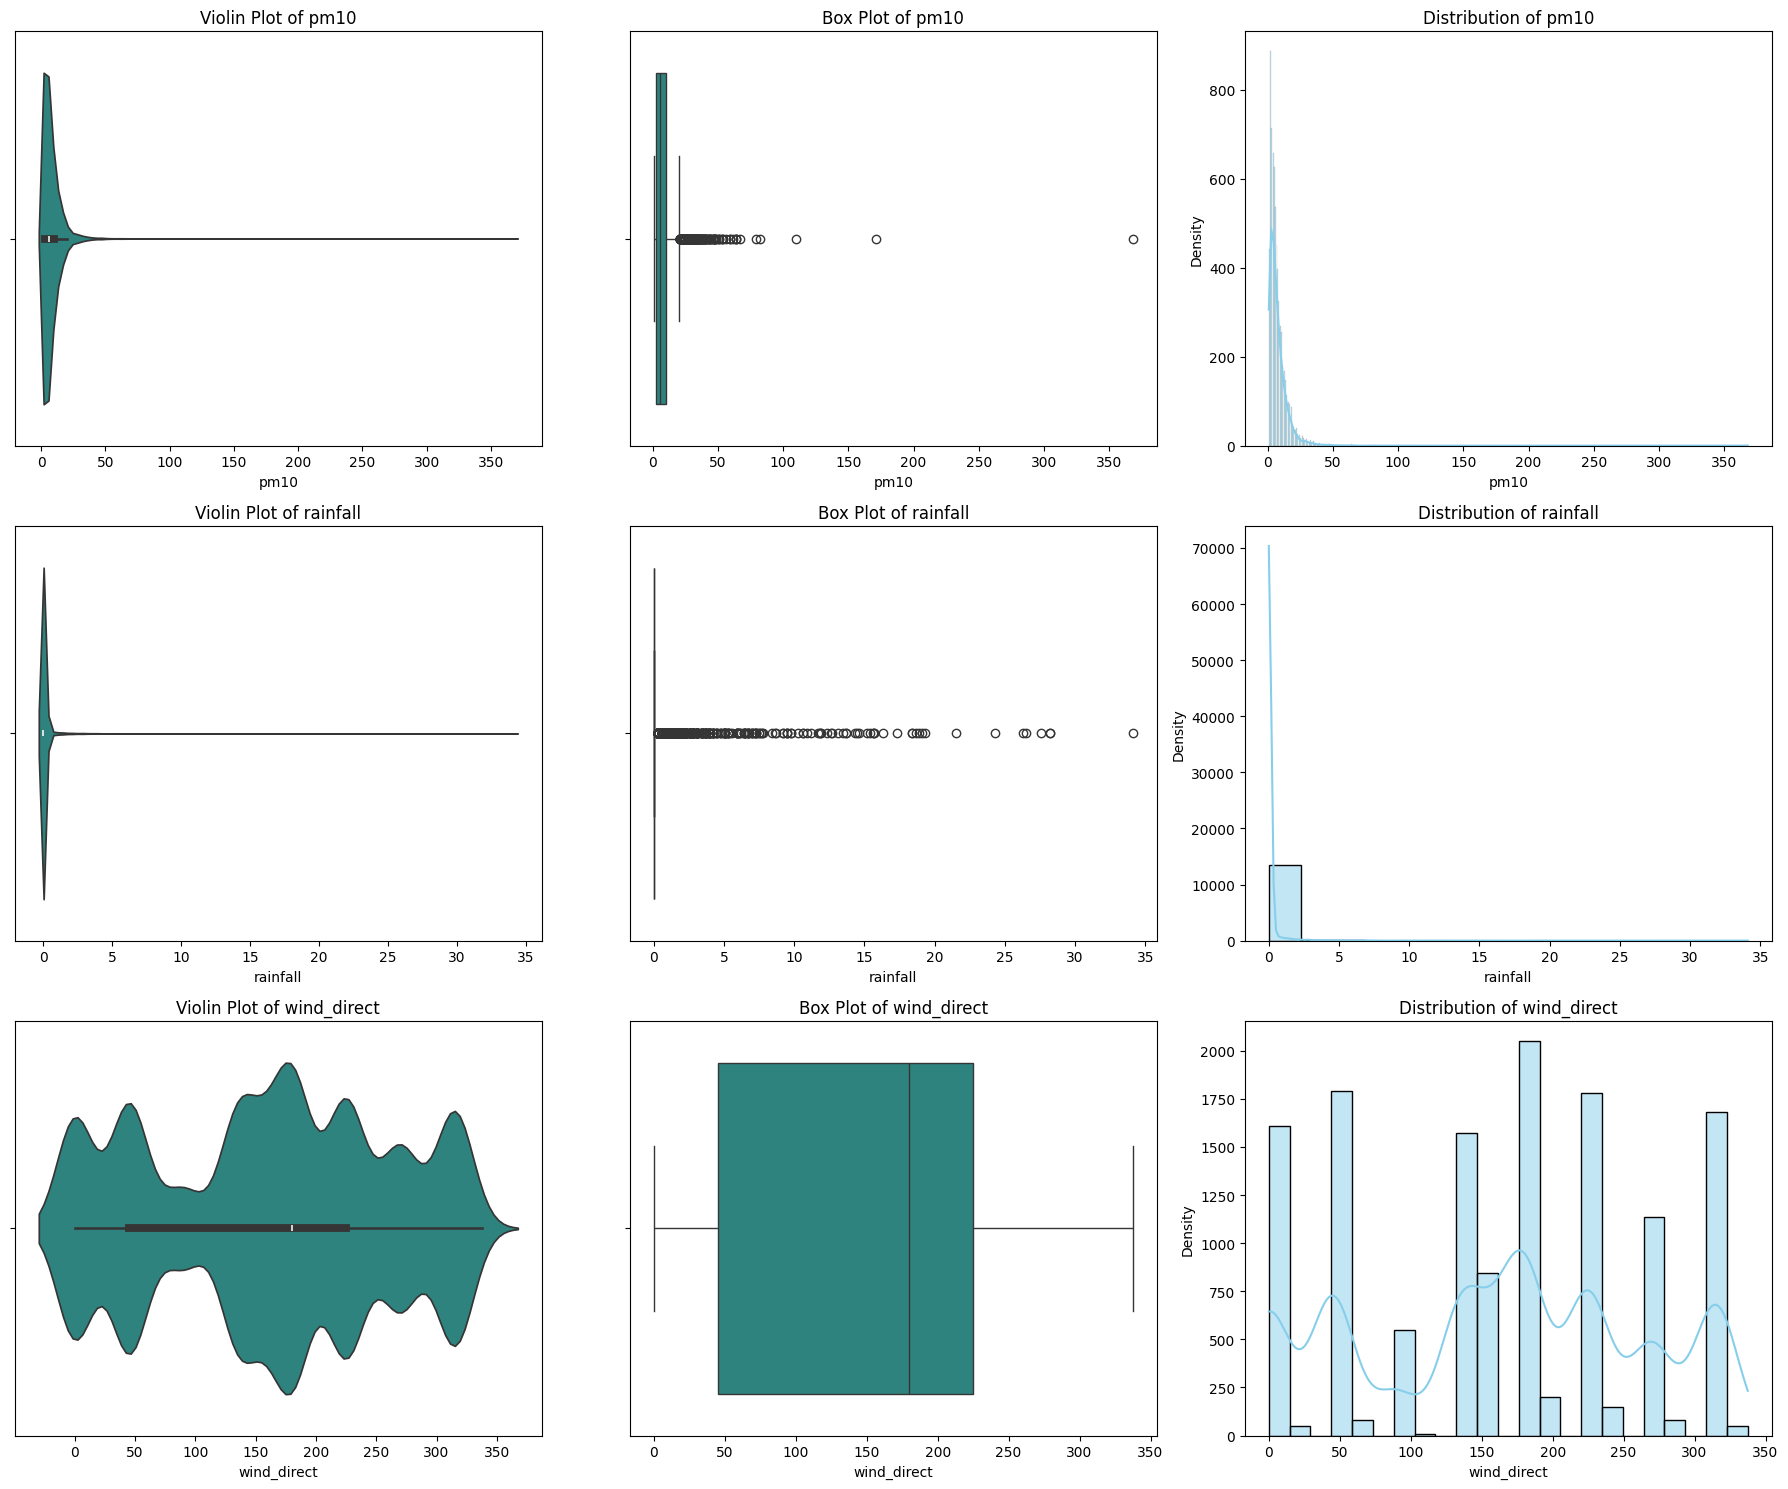

In [281]:
plot_violin_box_distribution(df_eda, columns=["pm10", "rainfall", "wind_direct"])

In [282]:
df_eda["pm2.5"].describe()

,pm2.5
count,6841.000000
mean,6.449203
std,8.415738
min,0.000000
25%,2.000000
50%,4.000000
75%,9.000000
max,368.000000


In [283]:
df_eda["pm10"].describe()

,pm10
count,6841.000000
mean,7.657652
std,8.449023
min,1.000000
25%,3.000000
50%,6.000000
75%,10.000000
max,368.000000


In [284]:
print(len(df_eda[df_eda['pm2.5'] >= 50]))
print(len(df_eda[df_eda['pm10'] >= 50]))

17
19


In [285]:
df_eda['pm2.5'] = df_eda['pm2.5'].clip(6, 50)
df_eda['pm10'] = df_eda['pm10'].clip(6, 50)

In [286]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13635 entries, 6361 to 6830
Data columns (total 62 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   tambon_code                           13635 non-null  int64  
 1   amphur_code                           13635 non-null  int64  
 2   province_code                         13635 non-null  int64  
 3   latitude                              13635 non-null  float64
 4   longitude                             13635 non-null  float64
 5   humid                                 13635 non-null  float64
 6   light                                 13635 non-null  float64
 7   pm10                                  6841 non-null   float64
 8   pm2.5                                 6841 non-null   float64
 9   rainfall                              13635 non-null  float64
 10  wind_direct                           13635 non-null  float64
 11  wind_speed        

In [287]:
df_eda = df_eda.drop(
    columns = [
        "tambon_code", "amphur_code", "province_code",
    ]
)

df_eda.describe()

,latitude,longitude,humid,light,pm10,pm2.5,rainfall,wind_direct,wind_speed,temp,...,time_weekofyear,time_quarter,time_is_weekend,time_season,time_is_month_start,time_is_month_end,time_is_quarter_start,time_is_quarter_end,time_hour_sin,time_hour_cos
count,13635.000000,13635.000000,13635.000000,13635.000000,6841.000000,6841.000000,13635.000000,13635.000000,13635.000000,13634.000000,...,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,1.363500e+04
mean,15.498114,101.728711,80.428258,33.196553,8.997807,8.498757,0.135827,161.854785,4.533869,29.083827,...,23.948442,2.334727,0.287055,2.664833,0.021122,0.031903,0.010781,0.011661,-0.001589,-3.037143e-04
std,2.345306,2.180078,12.442925,34.509041,5.792728,5.408871,1.112371,100.338928,181.668659,4.344476,...,3.754893,0.471912,0.452404,0.472066,0.143797,0.175749,0.103275,0.107359,0.706278,7.079848e-01
min,10.579849,98.573417,40.900000,0.000000,6.000000,6.000000,0.000000,0.000000,0.000000,17.200000,...,18.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000e+00
25%,14.533026,100.569662,71.000000,0.000000,6.000000,6.000000,0.000000,45.000000,0.000000,25.800000,...,21.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,-0.707107,-7.071068e-01
50%,16.494229,102.052114,82.400000,16.000000,6.000000,6.000000,0.000000,180.000000,1.400000,28.100000,...,24.000000,2.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.836970e-16
75%,18.142499,104.350891,90.600000,68.000000,10.000000,9.000000,0.000000,225.000000,3.400000,31.700000,...,27.000000,3.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.707107,7.071068e-01
max,18.241106,104.495172,100.000000,96.000000,50.000000,50.000000,34.100000,337.500000,15094.300000,51.100000,...,30.000000,3.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00


### Check Duplicate Columns

In [288]:
from collections import defaultdict

renamer = defaultdict()
renamer

defaultdict(None, {})

In [289]:
for column_name in df_eda.columns[df_eda.columns.duplicated(keep=False)].tolist():
    if column_name not in renamer:
      print(f"columns : {column_name}")
      #renamer[column_name] = [column_name+'_0']

    else:
      continue
      # renamer[column_name].append(column_name +'_'+str(len(renamer[column_name])))



columns : ดินแดง
columns : แม่สอด
columns : ดินแดง
columns : แม่สอด


In [290]:
df_eda = df_eda.drop(
    columns=["ดินแดง", "แม่สอด"]
)

df_eda

,latitude,longitude,humid,light,pm10,pm2.5,rainfall,wind_direct,wind_speed,temp,...,น่าน,บึงกาฬ,มุกดาหาร,ศรีสะเกษ,ขุนหาญ,ท่าแซะ,นาน้อย,ศรีวิไล,หนองสูง,โนนไทย
6361,10.579849,99.113146,93.0,0.0,NaN,NaN,0.0,90.0,1.3,25.2,...,False,False,False,False,False,True,False,False,False,False
8429,18.241106,100.690577,82.9,0.0,21.0,20.0,0.0,180.0,2.8,26.3,...,True,False,False,False,False,False,True,False,False,False
1678,15.112831,102.052114,94.7,0.0,NaN,NaN,0.9,45.0,5.8,22.5,...,False,False,False,False,False,False,False,False,False,True
11871,13.777972,100.569662,76.7,0.0,6.0,6.0,0.0,225.0,5.8,29.8,...,False,False,False,False,False,False,False,False,False,False
13614,16.494229,104.350891,97.7,0.0,NaN,NaN,1.5,45.0,4.9,19.6,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,15.112831,102.052114,92.2,0.0,NaN,NaN,21.5,0.0,6.3,24.5,...,False,False,False,False,False,False,False,False,False,True
10275,13.777972,100.569662,80.7,0.0,NaN,NaN,0.9,45.0,0.0,29.0,...,False,False,False,False,False,False,False,False,False,False
1806,18.142499,103.806521,85.6,0.0,6.0,6.0,0.0,0.0,0.0,28.4,...,False,True,False,False,False,False,False,True,False,False
8545,16.712990,98.573417,86.2,0.0,6.0,6.0,0.0,135.0,0.0,25.6,...,False,False,False,False,False,False,False,False,False,False


In [291]:
for column_name in df_eda.columns[df_eda.columns.duplicated(keep=False)].tolist():
    if column_name not in renamer:
      print(f"columns : {column_name}")
      #renamer[column_name] = [column_name+'_0']

    else:
      continue
      # renamer[column_name].append(column_name +'_'+str(len(renamer[column_name])))



In [292]:
nan_rows = df_eda[df_eda.isnull().T.any()]
nan_rows

,latitude,longitude,humid,light,pm10,pm2.5,rainfall,wind_direct,wind_speed,temp,...,น่าน,บึงกาฬ,มุกดาหาร,ศรีสะเกษ,ขุนหาญ,ท่าแซะ,นาน้อย,ศรีวิไล,หนองสูง,โนนไทย
6361,10.579849,99.113146,93.0,0.0,NaN,NaN,0.0,90.0,1.3,25.2,...,False,False,False,False,False,True,False,False,False,False
1678,15.112831,102.052114,94.7,0.0,NaN,NaN,0.9,45.0,5.8,22.5,...,False,False,False,False,False,False,False,False,False,True
13614,16.494229,104.350891,97.7,0.0,NaN,NaN,1.5,45.0,4.9,19.6,...,False,False,True,False,False,False,False,False,True,False
6641,10.579849,99.113146,92.7,5.0,NaN,NaN,0.0,315.0,0.0,25.3,...,False,False,False,False,False,True,False,False,False,False
105,15.112831,102.052114,94.9,9.0,NaN,NaN,1.5,45.0,8.3,21.6,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359,15.112831,102.052114,88.4,2.0,NaN,NaN,0.0,135.0,0.0,27.1,...,False,False,False,False,False,False,False,False,False,True
11585,13.777972,100.569662,78.2,0.0,NaN,NaN,0.9,45.0,1.2,29.2,...,False,False,False,False,False,False,False,False,False,False
12017,16.494229,104.350891,98.5,2.0,NaN,NaN,1.8,315.0,0.0,24.3,...,False,False,True,False,False,False,False,False,True,False
55,15.112831,102.052114,92.2,0.0,NaN,NaN,21.5,0.0,6.3,24.5,...,False,False,False,False,False,False,False,False,False,True


### Interpolation Fill Nan

In [293]:
# Fill NaN values in 'PM2.5' column using interpolation in the new DataFrame
df_eda['pm2.5'] = df_eda['pm2.5'].interpolate(method='linear')
df_eda['pm10'] = df_eda['pm10'].interpolate(method='linear')
df_eda['temp'] = df_eda['temp'].interpolate(method='linear')

In [294]:
nan_rows = df_eda[df_eda.isnull().T.any()]
nan_rows

,latitude,longitude,humid,light,pm10,pm2.5,rainfall,wind_direct,wind_speed,temp,...,น่าน,บึงกาฬ,มุกดาหาร,ศรีสะเกษ,ขุนหาญ,ท่าแซะ,นาน้อย,ศรีวิไล,หนองสูง,โนนไทย
6361,10.579849,99.113146,93.0,0.0,NaN,NaN,0.0,90.0,1.3,25.2,...,False,False,False,False,False,True,False,False,False,False


In [295]:
df_eda = df_eda.dropna()

nan_rows = df_eda[df_eda.isnull().T.any()]
nan_rows

,latitude,longitude,humid,light,pm10,pm2.5,rainfall,wind_direct,wind_speed,temp,...,น่าน,บึงกาฬ,มุกดาหาร,ศรีสะเกษ,ขุนหาญ,ท่าแซะ,นาน้อย,ศรีวิไล,หนองสูง,โนนไทย


### Time Feature Engineering

## AutoGluon Tabular Predict

In [296]:
!pip install autogluon

In [297]:
from autogluon.tabular import TabularDataset, TabularPredictor
from autogluon.common import space

train_data = df_eda.copy()
label = 'temp'

# From hackathon
metric = 'mae'

In [298]:
nn_options = {  # specifies non-default hyperparameter values for neural network models
    'num_epochs': 10,  # number of training epochs (controls training time of NN models)
    'learning_rate': space.Real(1e-4, 1e-2, default=5e-4, log=True),  # learning rate used in training (real-valued hyperparameter searched on log-scale)
    'activation': space.Categorical('relu', 'softrelu', 'tanh'),  # activation function used in NN (categorical hyperparameter, default = first entry)
    'dropout_prob': space.Real(0.0, 0.5, default=0.1),  # dropout probability (real-valued hyperparameter)
}

gbm_options = {  # specifies non-default hyperparameter values for lightGBM gradient boosted trees
    'num_boost_round': 100,  # number of boosting rounds (controls training time of GBM models)
    'num_leaves': space.Int(lower=26, upper=66, default=36),  # number of leaves in trees (integer hyperparameter)
}

 # NOTE: comment this line out if you get errors on Mac OSX
hyperparameters = { # hyperparameters of each model type
                   'GBM': gbm_options,
                    # NOTE: comment this line out if you get errors on Mac OSX
                   'NN_TORCH': nn_options,
                  }

time_limit = 4*60  # train various models for ~2 min
num_trials = 5  # try at most 5 different hyperparameter configurations for each type of model
search_strategy = 'auto'  # to tune hyperparameters using random search routine with a local scheduler

hyperparameter_tune_kwargs = {  # HPO is not performed unless hyperparameter_tune_kwargs is specified
    'num_trials': num_trials,
    'scheduler' : 'local',
    'searcher': search_strategy,
}

predictor = TabularPredictor(label=label, eval_metric=metric).fit(
    train_data,
    time_limit=time_limit,
    hyperparameters=hyperparameters,
    hyperparameter_tune_kwargs=hyperparameter_tune_kwargs,
)

No path specified. Models will be saved in: "AutogluonModels/ag-20250705_083858"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.1
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Mar 30 16:01:29 UTC 2025
CPU Count:          12
Memory Avail:       48.95 GB / 52.96 GB (92.4%)
Disk Space Avail:   192.89 GB / 235.68 GB (81.8%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competiti

  0%|          | 0/5 [00:00<?, ?it/s]

Fitted model: LightGBM/T1 ...
	-0.6029	 = Validation score   (-mean_absolute_error)
	2.39s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM/T2 ...
	-0.5661	 = Validation score   (-mean_absolute_error)
	4.64s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM/T3 ...
	-0.5888	 = Validation score   (-mean_absolute_error)
	0.56s	 = Training   runtime
	0.0s	 = Validation runtime
Fitted model: LightGBM/T4 ...
	-2.0536	 = Validation score   (-mean_absolute_error)
	0.45s	 = Training   runtime
	0.0s	 = Validation runtime
Fitted model: LightGBM/T5 ...
	-0.6614	 = Validation score   (-mean_absolute_error)
	0.5s	 = Training   runtime
	0.0s	 = Validation runtime
Hyperparameter tuning model: NeuralNetTorch ... Tuning model for up to 107.23s of the 229.56s of remaining time.


+---------------------------------------------------+
| Configuration for experiment     NeuralNetTorch   |
+---------------------------------------------------+
| Search algorithm                 SearchGenerator  |
| Scheduler                        FIFOScheduler    |
| Number of trials                 5                |
+---------------------------------------------------+

View detailed results here: /content/AutogluonModels/ag-20250705_083858/models/NeuralNetTorch


Fitted model: NeuralNetTorch/9b4aee67 ...
	-0.8027	 = Validation score   (-mean_absolute_error)
	4.84s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: NeuralNetTorch/bf55b056 ...
	-0.8983	 = Validation score   (-mean_absolute_error)
	4.82s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch/45660844 ...
	-0.9981	 = Validation score   (-mean_absolute_error)
	8.49s	 = Training   runtime
	0.03s	 = Validation runtime
Fitted model: NeuralNetTorch/a7204ed3 ...
	-1.1178	 = Validation score   (-mean_absolute_error)
	8.2s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: NeuralNetTorch/fadcd7e7 ...
	-0.8863	 = Validation score   (-mean_absolute_error)
	6.52s	 = Training   runtime
	0.02s	 = Validation runtime


Fitting model: WeightedEnsemble_L2 ... Training model for up to 238.29s of the 210.85s of remaining time.
	Ensemble Weights: {'LightGBM/T2': 0.882, 'LightGBM/T3': 0.118}
	-0.5656	 = Validation score   (-mean_absolute_error)
	0.05s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 29.23s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 140293.7 rows/s (2727 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/AutogluonModels/ag-20250705_083858")


## Transform Data Test

In [335]:
df_test = pd.read_csv("/content/IOT_Test.csv")
df_submission = pd.read_csv("/content/IOT_Submit.csv")
df_test

,id,mac,station_name,tambon_code,tambon_namt,amphur_code,amphur_namt,province_code,province_namt,latitude,longitude,time,humid,light,pm10,pm2.5,rainfall,wind_direct,wind_speed
0,1,3C71BF18EA64,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,2022-05-23 04:00:00+07:00,88.9,1.0,NaN,NaN,0.0,180.0,2.3
1,2,3C71BF18EA64,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,2022-05-12 16:00:00+07:00,85.0,40.0,NaN,NaN,0.3,135.0,1.5
2,3,3C71BF18EA64,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,2022-06-20 03:00:00+07:00,88.9,7.0,NaN,NaN,0.0,157.5,0.0
3,4,3C71BF18EA64,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,2022-07-13 13:00:00+07:00,81.9,66.0,NaN,NaN,0.0,135.0,0.2
4,5,3C71BF18EA64,บ้านนา_2,300903,กำปัง,3009,โนนไทย,30,นครราชสีมา,15.112831,102.052114,2022-07-05 09:00:00+07:00,64.9,71.0,NaN,NaN,0.0,225.0,2.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3408,3409,3C71BF18CEA4,โรงเรียนหนองสูงสามัคคีวิทยา_2,490706,หนองสูงเหนือ,4907,หนองสูง,49,มุกดาหาร,16.494229,104.350891,2022-06-05 03:00:00+07:00,87.0,0.0,NaN,NaN,0.0,315.0,0.0
3409,3410,3C71BF18CEA4,โรงเรียนหนองสูงสามัคคีวิทยา_2,490706,หนองสูงเหนือ,4907,หนองสูง,49,มุกดาหาร,16.494229,104.350891,2022-05-26 09:00:00+07:00,71.7,81.0,NaN,NaN,0.0,180.0,3.1
3410,3411,3C71BF18CEA4,โรงเรียนหนองสูงสามัคคีวิทยา_2,490706,หนองสูงเหนือ,4907,หนองสูง,49,มุกดาหาร,16.494229,104.350891,2022-05-21 22:00:00+07:00,86.5,2.0,NaN,NaN,0.0,0.0,0.6
3411,3412,3C71BF18CEA4,โรงเรียนหนองสูงสามัคคีวิทยา_2,490706,หนองสูงเหนือ,4907,หนองสูง,49,มุกดาหาร,16.494229,104.350891,2022-07-21 01:00:00+07:00,96.5,0.0,NaN,NaN,0.0,0.0,0.0


In [336]:
df_test["temp"] = np.nan

In [337]:
# Format Time
df_test["time"] = pd.to_datetime(df_test["time"])
df_test = df_test.sort_values(by="id")
df_test = extract_time_features(df=df_test, time_columns=["time"])
df_test = df_test.drop(columns=["time", "time_dt", "mac", "time_year", "time_is_year_start", "time_is_year_end"])
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3413 entries, 0 to 3412
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3413 non-null   int64  
 1   station_name           3413 non-null   object 
 2   tambon_code            3413 non-null   int64  
 3   tambon_namt            3413 non-null   object 
 4   amphur_code            3413 non-null   int64  
 5   amphur_namt            3413 non-null   object 
 6   province_code          3413 non-null   int64  
 7   province_namt          3413 non-null   object 
 8   latitude               3413 non-null   float64
 9   longitude              3413 non-null   float64
 10  humid                  3413 non-null   float64
 11  light                  3413 non-null   float64
 12  pm10                   1687 non-null   float64
 13  pm2.5                  1687 non-null   float64
 14  rainfall               3413 non-null   float64
 15  wind

In [338]:
# One Hot Encoding
df_test = onehot_encoding(df_test, 'station_name')
df_test = onehot_encoding(df_test, 'tambon_namt')
df_test = onehot_encoding(df_test, 'province_namt')
df_test = onehot_encoding(df_test, 'amphur_namt')

In [339]:
# Clip
df_test['pm2.5'] = df_test['pm2.5'].clip(6, 50)
df_test['pm10'] = df_test['pm10'].clip(6, 50)

# Interpolation
df_test['pm2.5'] = df_test['pm2.5'].interpolate(method='linear')
df_test['pm10'] = df_test['pm10'].interpolate(method='linear')

In [340]:
df_test

,id,tambon_code,amphur_code,province_code,latitude,longitude,humid,light,pm10,pm2.5,...,มุกดาหาร,ศรีสะเกษ,ขุนหาญ,ดินแดง,ท่าแซะ,นาน้อย,ศรีวิไล,หนองสูง,แม่สอด,โนนไทย
0,1,300903,3009,30,15.112831,102.052114,88.9,1.0,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
1,2,300903,3009,30,15.112831,102.052114,85.0,40.0,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
2,3,300903,3009,30,15.112831,102.052114,88.9,7.0,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
3,4,300903,3009,30,15.112831,102.052114,81.9,66.0,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
4,5,300903,3009,30,15.112831,102.052114,64.9,71.0,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3408,3409,490706,4907,49,16.494229,104.350891,87.0,0.0,6.0,6.0,...,True,False,False,False,False,False,False,True,False,False
3409,3410,490706,4907,49,16.494229,104.350891,71.7,81.0,6.0,6.0,...,True,False,False,False,False,False,False,True,False,False
3410,3411,490706,4907,49,16.494229,104.350891,86.5,2.0,6.0,6.0,...,True,False,False,False,False,False,False,True,False,False
3411,3412,490706,4907,49,16.494229,104.350891,96.5,0.0,6.0,6.0,...,True,False,False,False,False,False,False,True,False,False


## Prediction

In [344]:
y_pred = predictor.predict(df_test.drop(columns=[label]))
y_pred.head()

,temp
0,25.393595
1,28.206308
2,25.378334
3,29.313789
4,34.430180


In [345]:
y_pred = y_pred.reset_index()
y_pred = y_pred.rename(columns={"index":"id"})
y_pred["id"] = y_pred["id"] + 1

In [346]:
y_pred

,id,temp
0,1,25.393595
1,2,28.206308
2,3,25.378334
3,4,29.313789
4,5,34.430180
...,...,...
3408,3409,25.992052
3409,3410,32.920578
3410,3411,26.986519
3411,3412,24.990715


In [347]:
df_submission

,id,temp
0,1,25.6
1,2,30.1
2,3,24.7
3,4,NaN
4,5,NaN
...,...,...
3408,3409,NaN
3409,3410,NaN
3410,3411,NaN
3411,3412,NaN


In [348]:
y_pred.to_csv("Tabular_Gluon_TimeExtractorOnly.csv")